<a href="https://colab.research.google.com/github/Vishalization/Skin_Disease_Classification/blob/main/Vishal_ResNet_with_aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/skin_split.rar" /content/

In [ ]:
!ls /content

drive  sample_data  skin_split	skin_split.rar


In [3]:
!apt-get install unrar
!unrar x /content/skin_split.rar /content/

Streaming output truncated to the last 5000 lines.
Extracting  /content/skin_split/train/nv/ISIC_0025194.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025198.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025200.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025201.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025202.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025203.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025204.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025205.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025206.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025207.jpg                 50%  OK 
Extracting  /content/skin_spl

In [4]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn

In [5]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report
from tensorflow.keras.applications.resnet import preprocess_input


In [6]:
from tensorflow.keras.regularizers import l2

In [7]:
# path for training and testing data
train_dir = "/content/skin_split/train"
test_dir = "/content/skin_split/test"

In [8]:
# data augmentation for training data
train_datagen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
   rotation_range=30,
   width_shift_range=0.1,
   height_shift_range=0.1,
   shear_range=0.1,
   zoom_range=0.2,
   horizontal_flip=True,
   fill_mode='nearest',
   validation_split=0.15
)

In [9]:
# generate data for training and validation data set
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 6813 images belonging to 7 classes.
Found 1197 images belonging to 7 classes.


In [10]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2005 images belonging to 7 classes.


In [11]:
#class weight as the HAM10000 is imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights using training labels
classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.384169884169884), 1: np.float64(2.780816326530612), 2: np.float64(1.3011841100076393), 3: np.float64(12.320072332730561), 4: np.float64(1.2857142857142858), 5: np.float64(0.21343984962406015), 6: np.float64(10.033873343151694)}


In [12]:
# model download and configuration
from tensorflow.keras.applications import *
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.applications import InceptionResNetV2

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers :
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)

#x = BatchNormalization()(x)
#x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
#x = Dropout(0.3)(x)

x = Dense(7, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=x)


tl_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 24,065,031 (91.80 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [13]:
#optimizer
optimizer = Adam(0.0001)
tl_model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [14]:
# LearningRate; EarlyStopping; ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficent_skin_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [lr_reduce, early_stop, checkpoint]

In [15]:

#first training training or compiling
history = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)



Epoch 1/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.3948 - loss: 2.4796
Epoch 1: val_accuracy improved from None to 0.69173, saving model to best_efficent_skin_model.keras

Epoch 1: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.4571 - loss: 2.0807 - val_accuracy: 0.6917 - val_loss: 1.4925 - learning_rate: 1.0000e-04
Epoch 2/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.5837 - loss: 1.4595
Epoch 2: val_accuracy improved from 0.69173 to 0.70927, saving model to best_efficent_skin_model.keras

Epoch 2: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 173s 813ms/step - accuracy: 0.5807 - loss: 1.4829 - val_accuracy: 0.7093 - val_loss: 1.1920 - learning_rate: 1.0000e-04
Epoch 3/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.6234 - loss: 1.3492
Epoch 3: val_accuracy did not improve from 0.70927
213/213 ━━━━━━━━━━━━━━━━━━━━ 162s 761ms/step - accuracy

In [16]:

# freeze most layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

# unfreeze top layers
for layer in base_model.layers[-15:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

tl_model.compile(
 optimizer=Adam(1e-5),
 loss='categorical_crossentropy',
 metrics=['accuracy']
)

fine_tune_history = tl_model.fit(
 train_generator,
 validation_data=val_generator,
 epochs=10,
 callbacks=callbacks,
 class_weight=class_weights
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.6481 - loss: 1.2459
Epoch 1: val_accuracy improved from 0.71596 to 0.73350, saving model to best_efficent_skin_model.keras

Epoch 1: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 180s 772ms/step - accuracy: 0.6570 - loss: 1.2169 - val_accuracy: 0.7335 - val_loss: 1.1715 - learning_rate: 1.0000e-05
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.6887 - loss: 1.1393
Epoch 2: val_accuracy did not improve from 0.73350
213/213 ━━━━━━━━━━━━━━━━━━━━ 147s 692ms/step - accuracy: 0.6774 - loss: 1.1501 - val_accuracy: 0.7285 - val_loss: 1.1590 - learning_rate: 1.0000e-05
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.6782 - loss: 1.1309
Epoch 3: val_accuracy did not improve from 0.73350
213/213 ━━━━━━━━━━━━━━━━━━━━ 165s 777ms/step - accuracy: 0.6855 - loss: 1.1313 - val_accuracy: 0.7235 - val_loss: 1.1718 - learning_rate: 1.0000e-05
Epoch 4/10
213/213

In [17]:
df=pd.DataFrame(tl_model.history.history)
df.to_csv('hist.csv')

<Axes: >

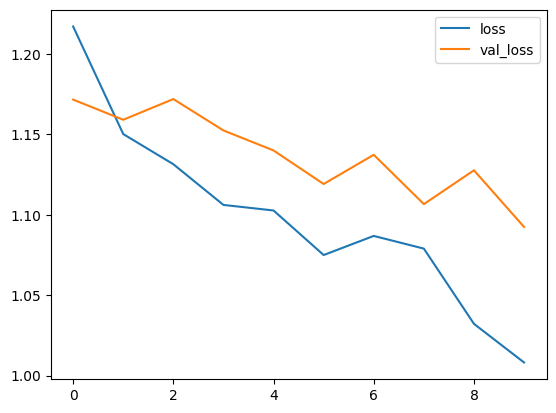

In [18]:
metrics = pd.DataFrame(tl_model.history.history)
metrics[["loss","val_loss"]].plot()

<Axes: >

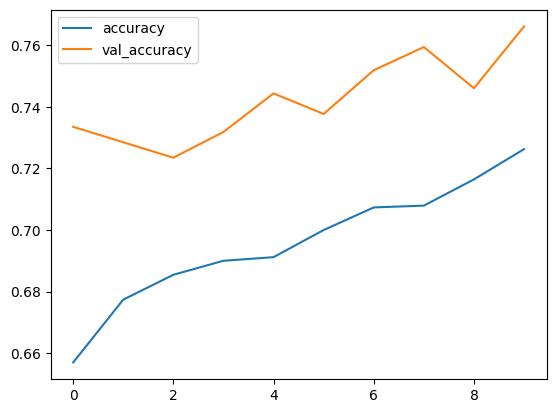

In [19]:
metrics[["accuracy","val_accuracy"]].plot()

In [20]:
tl_model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 355ms/step - accuracy: 0.7162 - loss: 1.2024


[1.202370285987854, 0.7162094712257385]

In [21]:
predictions = tl_model.predict(test_generator, verbose=1)
predictions = predictions.argmax(axis=1)

test_labels = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 304ms/step


In [22]:
import sklearn
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(test_labels, predictions)

Normalized confusion matrix


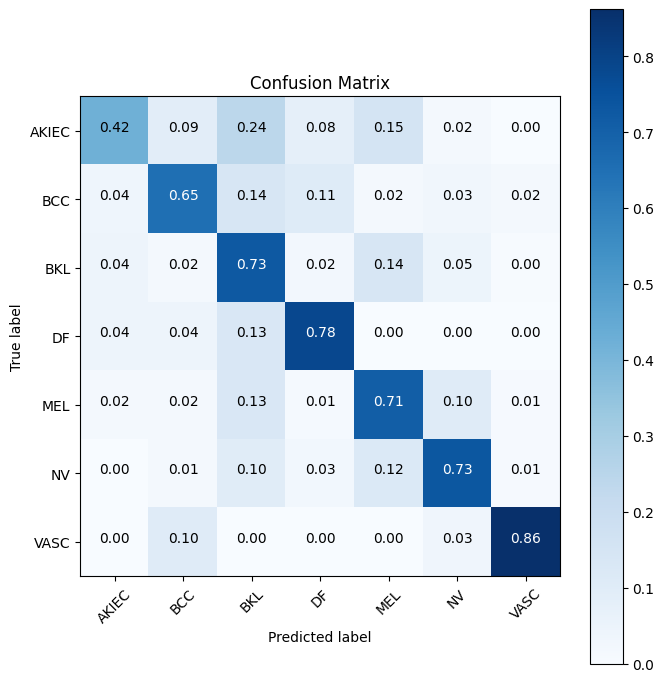

In [23]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        print(cm)

    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels =['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)


In [24]:
!pip install disarray
import disarray

# Instantiate the confusion matrix DataFrame with index and columns
#cm = confusion_matrix(a,b)
df = pd.DataFrame(cm, index= ['AKIEC','BCC','BKL','DF','MEL','NV','VASC'], columns=['AKIEC','BCC','BKL','DF','MEL','NV','VASC'])
df.da.export_metrics()

,AKIEC,BCC,BKL,DF,MEL,NV,VASC,micro-average
accuracy,0.971072,0.963591,0.872319,0.968080,0.866833,0.800998,0.989526,0.918917
f1,0.491228,0.647343,0.555556,0.360000,0.542024,0.830861,0.704225,0.716209
false_discovery_rate,0.416667,0.355769,0.550562,0.766234,0.561111,0.037328,0.404762,0.283791
false_negative_rate,0.575758,0.349515,0.272727,0.217391,0.291480,0.269202,0.137931,0.283791
false_positive_rate,0.010315,0.019453,0.109804,0.029768,0.113356,0.057229,0.008603,0.047298
negative_predictive_value,0.980583,0.981063,0.963614,0.997407,0.960486,0.634245,0.997962,0.952702
positive_predictive_value,0.583333,0.644231,0.449438,0.233766,0.438889,0.962672,0.595238,0.716209
precision,0.583333,0.644231,0.449438,0.233766,0.438889,0.962672,0.595238,0.716209
recall,0.424242,0.650485,0.727273,0.782609,0.708520,0.730798,0.862069,0.716209
sensitivity,0.424242,0.650485,0.727273,0.782609,0.708520,0.730798,0.862069,0.716209


In [ ]:
#downloading the best model
!zip skin_model.zip best_efficent_skin_model.keras
!ls
from google.colab import files
files.download("skin_model.zip")

  adding: best_efficent_skin_model.keras (deflated 10%)
best_efficent_skin_model.keras	hist.csv     skin_model.zip  skin_split.rar
drive				sample_data  skin_split


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>